# Экспериментальное исследование алгоритмов для регулярных запросов

## Постановка задачи

Задача посвящена анализу производительности следующих задач достижимости с регулярными ограничениями (Regular Path Querying, RPQ):
- Достижимость между всеми парами вершин.
- Достижимость для каждой из заданного множества стартовых вершин.

Вопросы, на которые необходимо ответить в ходе исследования:

- Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?
- Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?


## Описание исследуемых решений

Рассматриваемые решения реализованы в задачах №3 и №4 соответственно.

### Регулярные запросы для всех пар вершин (Tensor-based RPQ)

Решение на основе тензорного произведения. Ограничения в данной задаче заданы регулярными выражениями, по которым можно построить конечные автоматы. Булевая декомпозиция конечного автомата, построенного по графу, пересекается с булевой декомпозицией конечного автомата, построенным по регулярному выражению путем построения тензорного произведения соответствующих матриц смежности. Объединяем все элементы получившейся булевой декомпозиции.
В решении мы работаем с разреженными матрицы смежности из [sciPy](https://docs.scipy.org/doc/scipy/reference/sparse.html) и информацией о стартовых и финальных вершинах. 

Поскольку перед нами стоит задача отвечать на вопрос о достижимости, нам потребуется дополнительно рассчитать транзитивное замыкание путём последовательного возведения матрицы в степень до тех пор, пока результат не перестанет меняться. Результатом работы алгоритма является набор пары вершин из заданных стартовых и финальных, которые связанны путём, формирующем слово из языка, задаваемого регулярным выражением.

### Регулярные запросы для нескольких стартовых вершин (MS BFS-based RPQ)

Алгоритм поиска достижимости от нескольких стартовых вершин через обход в ширину (Multiple-Source BFS), основанный на линейной алгебре. Идея алгоритма основана на одновременном обходе в ширину графа и конечного автомата, построенного по грамматике/регулярному выражению. 

Создаются булевы декомпозиции, построенные из автоматов графа и регулярного выражения. Далее, мы оперируем с двумя словарями, где ключом является символ метки ребра графа или символ алфавита автомата, а значением — соответствующая им булевая матрица. Для каждого символа из пересечения этих множеств строится матрица $D$ как прямая сумма булевых матриц (блочно-диагональная матрица, составленная из исходных матриц, расположенных по диагонали). Для каждой стартовой вершины формируется матрица состояния (фронт), отражающая текущее множество пар (вершина графа, состояние автомата, соответствующего регулярному выражению запроса). Умножаем фронт на элементы булевой декомпозиции, складываем результат (новые достижимые состояния, соответствующие ограничениям) к числу посещенных состояний. Все это повторяется до тех пор, пока матрица состояний (фронтов) не станет пустой (т.е. не появятся новые достижимые состояния). 

Результатом работы алгоритма будет множество пар вершин $(v, w)$ графа таких, что вершина $w$ достижима из множества начальных вершин, а $v$ принадлежит множеству начальных вершин

## Набор данных

### Графы

Графы были выбраны из набора [CFPQ_Data](https://formallanguageconstrainedpathquerying.github.io/CFPQ_Data/graphs/index.html). 

В таблице приведены данные графов, выбранных для исследования:

| Граф  | Количество вершин | Количество ребер | Уникальные метки |
|-------|-------------------|------------------|------------------|
| atom  | 291               | 425              | 17               |
| foaf  | 256               | 631              | 15               |
| wc    | 332               | 269              | 2                |
| skos  | 144               | 252              | 21               |

Выбор такого набора обусловлен различиями в их плотности (соотношении числа вершин и ребер). В него вошли как сбалансированные структуры, так и графы с преобладанием ребер над вершинами. Кроме того, при формировании выборки учитывался размер графов: он выбирался таким образом, чтобы обеспечить возможность проведения измерений за приемлемое время.

### Запросы

Запросы сформированы по шаблону, использующий все основные операции над регулярными языками (замыкание, конкатенация, альтернатива):

- ```(l1 | l2)* l3```
- ```(l3 | l4)+ l1*```
- ```l1 l2 l3 (l4|l1)*```
- ```l1 (l2 | l3)* l4 ```

Где $l1$,&ensp;$l2$,&ensp;$l3$,&ensp;$l4$ — самые часто встречающиеся метки в графе (если меток всего 2, как у ```wc```, то считаем, что $l1$&ensp;=&ensp;$l3$,&ensp;а &ensp;$l2$&ensp;=&ensp;$l4$).

Запросы различаются по количеству состояний и переходов в конечном автомате, что влияет на размер и разреженность матрицы смежности.

## Оборудование

- **Операционная система**: MacOS Sequoia 15.6.1
- **Процессор**: Apple M2 8 ядер
- **ОЗУ**: 8GB RAM
- **ПЗУ**: 256GB SSD
- **Версия Python**: 3.12.5

## Этапы проведения эксперимента

#### 1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач?

Были выбраны четыре представления разреженных матриц:
- **[csr_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.html#scipy.sparse.csr_matrix)**. Матрица CSR (Compressed Sparse Row) представляет собой сжатое строчное хранение. Это три массива, где первый хранит значения ненулевых элементов, идущие подряд по строкам, второй хранит столбцовые индексы для каждого элемента первого массива, а третий массив длиной n_rows + 1 указывает на индексы в первом массиве, с которого начинается и заканчивается строка i по ненулевым элементам.
- **[csc_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csc_matrix.html#scipy.sparse.csc_matrix)**. Матрица CSC аналогична CSR, но с точностью до наоборот (транспонированная логика). Первый массив — значения ненулевых элементов, идущие подряд по столбцам, второй — строчные индексы для каждого элемента из первого массива, третий хранит указатели столбцов на ненулевые элементы из первого массива.
- **[dok_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.dok_matrix.html#scipy.sparse.dok_matrix)**. 
Матрица DOK (Dictionary of Keys) хранится в виде одного большого словаря (хэш-таблицы), где ключом является кортеж (row_index, column_index), а значением — сам элемент.
- **[lil_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html#scipy.sparse.lil_matrix)**. 
Матрица формата LIL (List of Lists) представляется в виде списка строк. Каждая строка — это список (или словарь), содержащий пары (column_index, value) только для ненулевых элементов.

Все они являются частью библиотеки `scipy.sparse` и поддерживают все необходимые в ходе эксперимента операции. Для каждой комбинации типа разреженной матрицы, графа и регулярного выражения оба алгоритма выполняются по 20 раз. В качестве стартовых и финальных вершин графа выберем все вершины. 

#### 2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

Размер стартового множества определяется процентом от общего числа вершин графа, и в качестве рассматриваемых размеров стартовых множеств были выбраны 10%, 30%, 70% и 100% - такой набор позволит рассмотреть большой диапазон значений при относительно небольшых количествах запусков.

Для каждого регулярного выражения и каждого графа будут проводиться измерения времени выполнения обоих алгоритмов при различных размерах стартового множества. Как и в ответе для первого вопроса, для каждой конфигурации будет 20 запусков.



В качестве итоговой оценки производительности для ответа на оба вопроса будет использоваться среднее время выполнения, а также рассчитан 95% доверительный интервал.


## Ход эксперимента

### Импорты и глобальные переменные

In [ ]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd()))

import cfpq_data
import logging
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import scipy.sparse as sp

from scipy.sparse import csc_matrix, csr_matrix, dok_matrix, lil_matrix
from collections import defaultdict, Counter
from cfpq_data import get_sorted_labels
from functools import reduce
from itertools import product
from networkx import MultiDiGraph
from scipy.sparse import vstack
from typing import Type
from pyformlang.finite_automaton import Symbol
from typing import Iterable
from scipy.sparse import kron

from project.task2_fa import graph_to_nfa, regex_to_dfa, NondeterministicFiniteAutomaton
from project.task3 import tensor_based_rpq
from project.task4 import ms_bfs_based_rpq

logging.getLogger().setLevel(logging.ERROR)


NUM_RUNS = 20
GRAPHS_NAMES = ["atom", "foaf", "wc", "skos"]
SCIPY_MATRIX = [csc_matrix, csr_matrix, dok_matrix, lil_matrix]
REGEX_TEMPLATES = [
    "(l1|l2)* · l3",
    "(l3|l4)+ · l1*",
    "(l1 · l2 · l3 · (l4|l1)*)",
    "(l1 · (l2|l3)* · l4)",
]

### Сравнение графов

In [3]:
graphs_info = defaultdict(dict)

for name in GRAPHS_NAMES:
    path = cfpq_data.download(name)
    g = cfpq_data.graph_from_csv(path)

    vertices = g.number_of_nodes()
    edges = g.number_of_edges()

    labels = set()
    for _, _, data in g.edges(data=True):
        labels.add(data["label"])

    graphs_info[name] = {"vertices": vertices, "edges": edges, "labels": labels}

In [4]:
for name, info in graphs_info.items():
    print(f"{name}")
    for key, value in info.items():
        print(f"  - {key}: {value}")

atom
  - vertices: 291
  - edges: 425
  - labels: {'title', 'comment', 'creator', 'versionInfo', 'range', 'imports', 'seeAlso', 'type', 'subPropertyOf', 'format', 'subClassOf', 'label', 'language', 'date', 'publisher', 'domain', 'description'}
foaf
  - vertices: 256
  - edges: 631
  - labels: {'title', 'comment', 'equivalentClass', 'range', 'type', 'disjointWith', 'subPropertyOf', 'inverseOf', 'isDefinedBy', 'label', 'subClassOf', 'equivalentProperty', 'domain', 'term_status', 'description'}
wc
  - vertices: 332
  - edges: 269
  - labels: {'d', 'a'}
skos
  - vertices: 144
  - edges: 252
  - labels: {'contributor', 'inverseOf', 'definition', 'title', 'range', 'seeAlso', 'disjointWith', 'isDefinedBy', 'subClassOf', 'unionOf', 'subPropertyOf', 'rest', 'comment', 'type', 'example', 'domain', 'first', 'description', 'creator', 'scopeNote', 'label'}


Визуализируем статистику

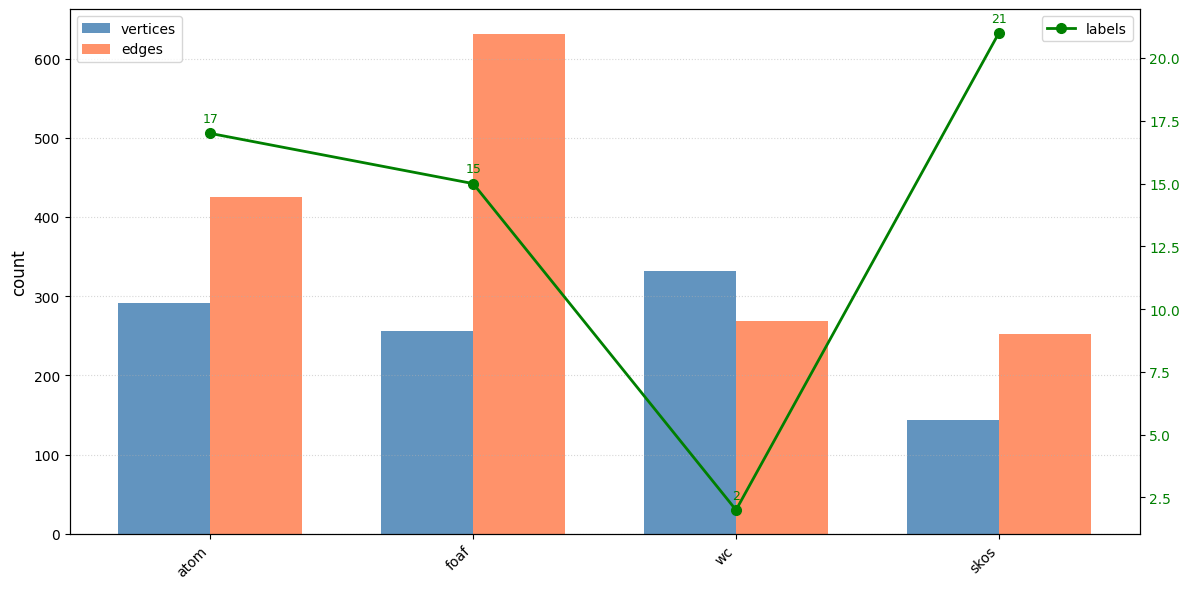

In [5]:
vertices = [graphs_info[n]["vertices"] for n in GRAPHS_NAMES]
edges = [graphs_info[n]["edges"] for n in GRAPHS_NAMES]
n_labels = [len(graphs_info[n]["labels"]) for n in GRAPHS_NAMES]

x = np.arange(len(GRAPHS_NAMES))
bar_width = 0.35

fig, ax1 = plt.subplots(figsize=(12, 6))

bars1 = ax1.bar(
    x - bar_width / 2,
    vertices,
    bar_width,
    label="vertices",
    color="steelblue",
    alpha=0.85,
)
bars2 = ax1.bar(
    x + bar_width / 2, edges, bar_width, label="edges", color="coral", alpha=0.85
)

ax1.set_ylabel("count", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(GRAPHS_NAMES, rotation=45, ha="right", fontsize=10)
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.5, axis="y", zorder=0)

ax2 = ax1.twinx()
ax2.plot(
    x,
    n_labels,
    marker="o",
    color="green",
    linewidth=2,
    markersize=7,
    label="labels",
    zorder=3,
)
ax2.tick_params(axis="y", labelcolor="green")
ax2.legend(loc="upper right", fontsize=10)

for i, val in enumerate(n_labels):
    ax2.annotate(
        str(val),
        (x[i], val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        color="green",
    )
plt.tight_layout()
plt.show()

### Вопрос 1. Какое представление разреженных матриц и векторов лучше подходит для каждой из решаемых задач

Формируем регулярное выражение на основе четырех меток

In [6]:
def build_regex_from_labels(labels):
    if len(labels) < 4:
        l1, l2, *_ = labels
        return [
            f"({l1}|{l2})* {l1}",
            f"({l1}|{l2})+ {l1}*",
            f"({l1} {l2} {l1} ({l2}|{l1})*)",
            f"({l1} ({l2}|{l1})* {l2})",
        ]
    else:
        l1, l2, l3, l4, *_ = labels
        return [
            f"({l1}|{l2})* {l3}",
            f"({l3}|{l4})+ {l1}*",
            f"({l1} {l2} {l3} ({l4}|{l1})*)",
            f"({l1} ({l2}|{l3})* {l4})",
        ]

In [7]:
graphs = {g: cfpq_data.graph_from_csv(cfpq_data.download(g)) for g in GRAPHS_NAMES}
methods = ["tensor_based_rpq", "ms_bfs_based_rpq"]

In [8]:
def run(method, graph, regex, matrix):
    times = []

    for _ in range(NUM_RUNS):
        start_time = time.time()
        if method == "tensor_based_rpq":
            tensor_based_rpq(regex, graph, graph.nodes, graph.nodes, matrix)
        elif method == "ms_bfs_based_rpq":
            ms_bfs_based_rpq(regex, graph, graph.nodes, graph.nodes, matrix)
        else:
            raise Exception("this algorithm is not supported")

        final_time = time.time()
        times.append(final_time - start_time)

    avg = sum(times) / len(times)

    return avg

In [9]:
results = []

for method in methods:
    for name, graph in graphs.items():
        labels = get_sorted_labels(graph)
        most_common_labels = [label for label, _ in Counter(labels).most_common(4)]
        regexes = build_regex_from_labels(labels)

        print(method)
        print(f"graph {name}")
        print(labels)
        print(most_common_labels)
        print(regexes)

        for regex_idx, regex in enumerate(regexes):
            for matrix in SCIPY_MATRIX:
                res_time = run(method, graph, regex, matrix)

                results.append(
                    {
                        "method": method,
                        "regex": regex,
                        "regex_template": REGEX_TEMPLATES[regex_idx],
                        "graph": name,
                        "matrix": matrix.__name__,
                        "avg_time": res_time,
                    }
                )

tensor_based_rpq
graph atom
['type', 'label', 'subClassOf', 'comment', 'domain', 'range', 'subPropertyOf', 'creator', 'date', 'description', 'format', 'imports', 'language', 'publisher', 'seeAlso', 'title', 'versionInfo']
['type', 'label', 'subClassOf', 'comment']
['(type|label)* subClassOf', '(subClassOf|comment)+ type*', '(type label subClassOf (comment|type)*)', '(type (label|subClassOf)* comment)']


/Users/kseniia/formal-lang-course/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/kseniia/formal-lang-course/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


tensor_based_rpq
graph foaf
['type', 'label', 'comment', 'term_status', 'isDefinedBy', 'domain', 'range', 'subPropertyOf', 'subClassOf', 'disjointWith', 'inverseOf', 'equivalentClass', 'description', 'equivalentProperty', 'title']
['type', 'label', 'comment', 'term_status']
['(type|label)* comment', '(comment|term_status)+ type*', '(type label comment (term_status|type)*)', '(type (label|comment)* term_status)']
tensor_based_rpq
graph wc
['d', 'a']
['d', 'a']
['(d|a)* d', '(d|a)+ d*', '(d a d (a|d)*)', '(d (a|d)* a)']
tensor_based_rpq
graph skos
['type', 'definition', 'isDefinedBy', 'label', 'subPropertyOf', 'comment', 'scopeNote', 'inverseOf', 'range', 'domain', 'contributor', 'disjointWith', 'creator', 'example', 'first', 'rest', 'description', 'seeAlso', 'subClassOf', 'title', 'unionOf']
['type', 'definition', 'isDefinedBy', 'label']
['(type|definition)* isDefinedBy', '(isDefinedBy|label)+ type*', '(type definition isDefinedBy (label|type)*)', '(type (definition|isDefinedBy)* label)

In [11]:
df = pd.DataFrame(results)
df

,method,regex,regex_template,graph,matrix,avg_time
0,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csc_matrix,0.451683
1,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csr_matrix,0.444925
2,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,dok_matrix,0.435311
3,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,lil_matrix,0.453595
4,tensor_based_rpq,(subClassOf|comment)+ type*,(l3|l4)+ · l1*,atom,csc_matrix,1.250575
...,...,...,...,...,...,...
123,ms_bfs_based_rpq,(type definition isDefinedBy (label|type)*),(l1 · l2 · l3 · (l4|l1)*),skos,lil_matrix,0.087698
124,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csc_matrix,0.091331
125,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csr_matrix,0.086081
126,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,dok_matrix,0.109267


In [12]:
MATRIX_TYPES = sorted(df["matrix"].unique())
DF_REGEX = list(df["regex_template"].unique())

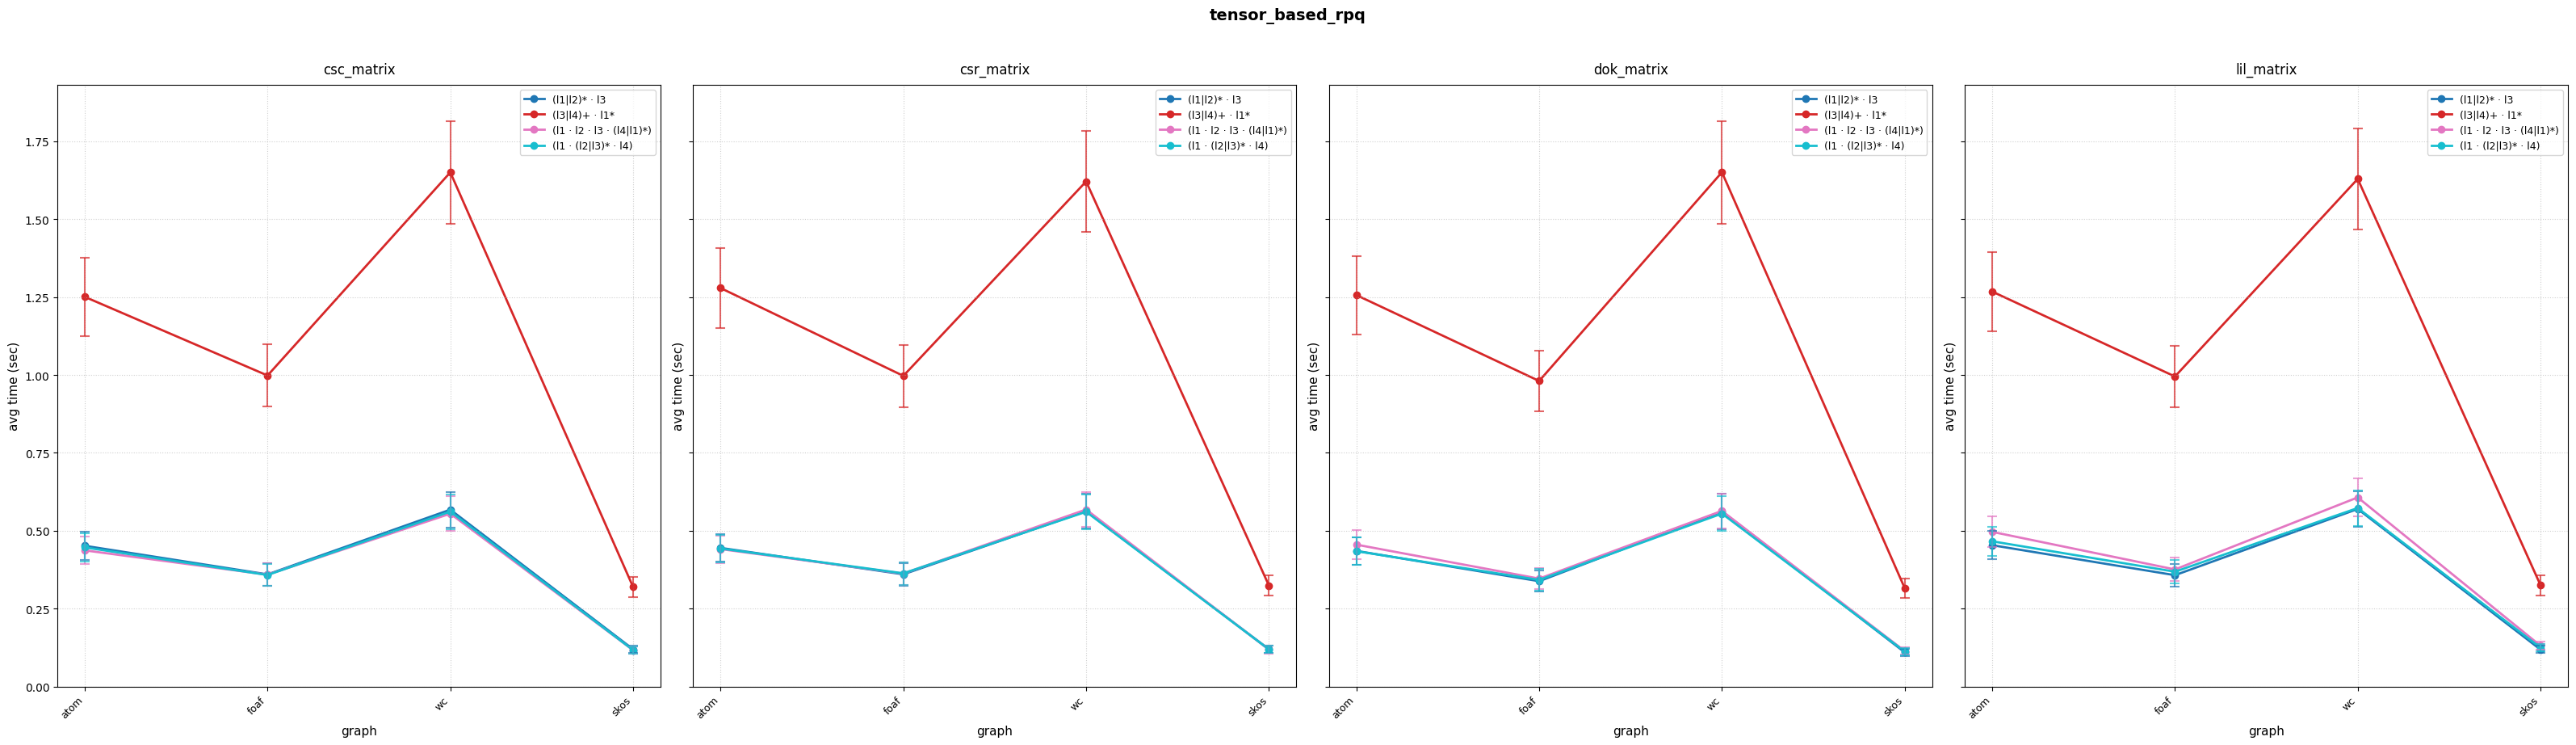

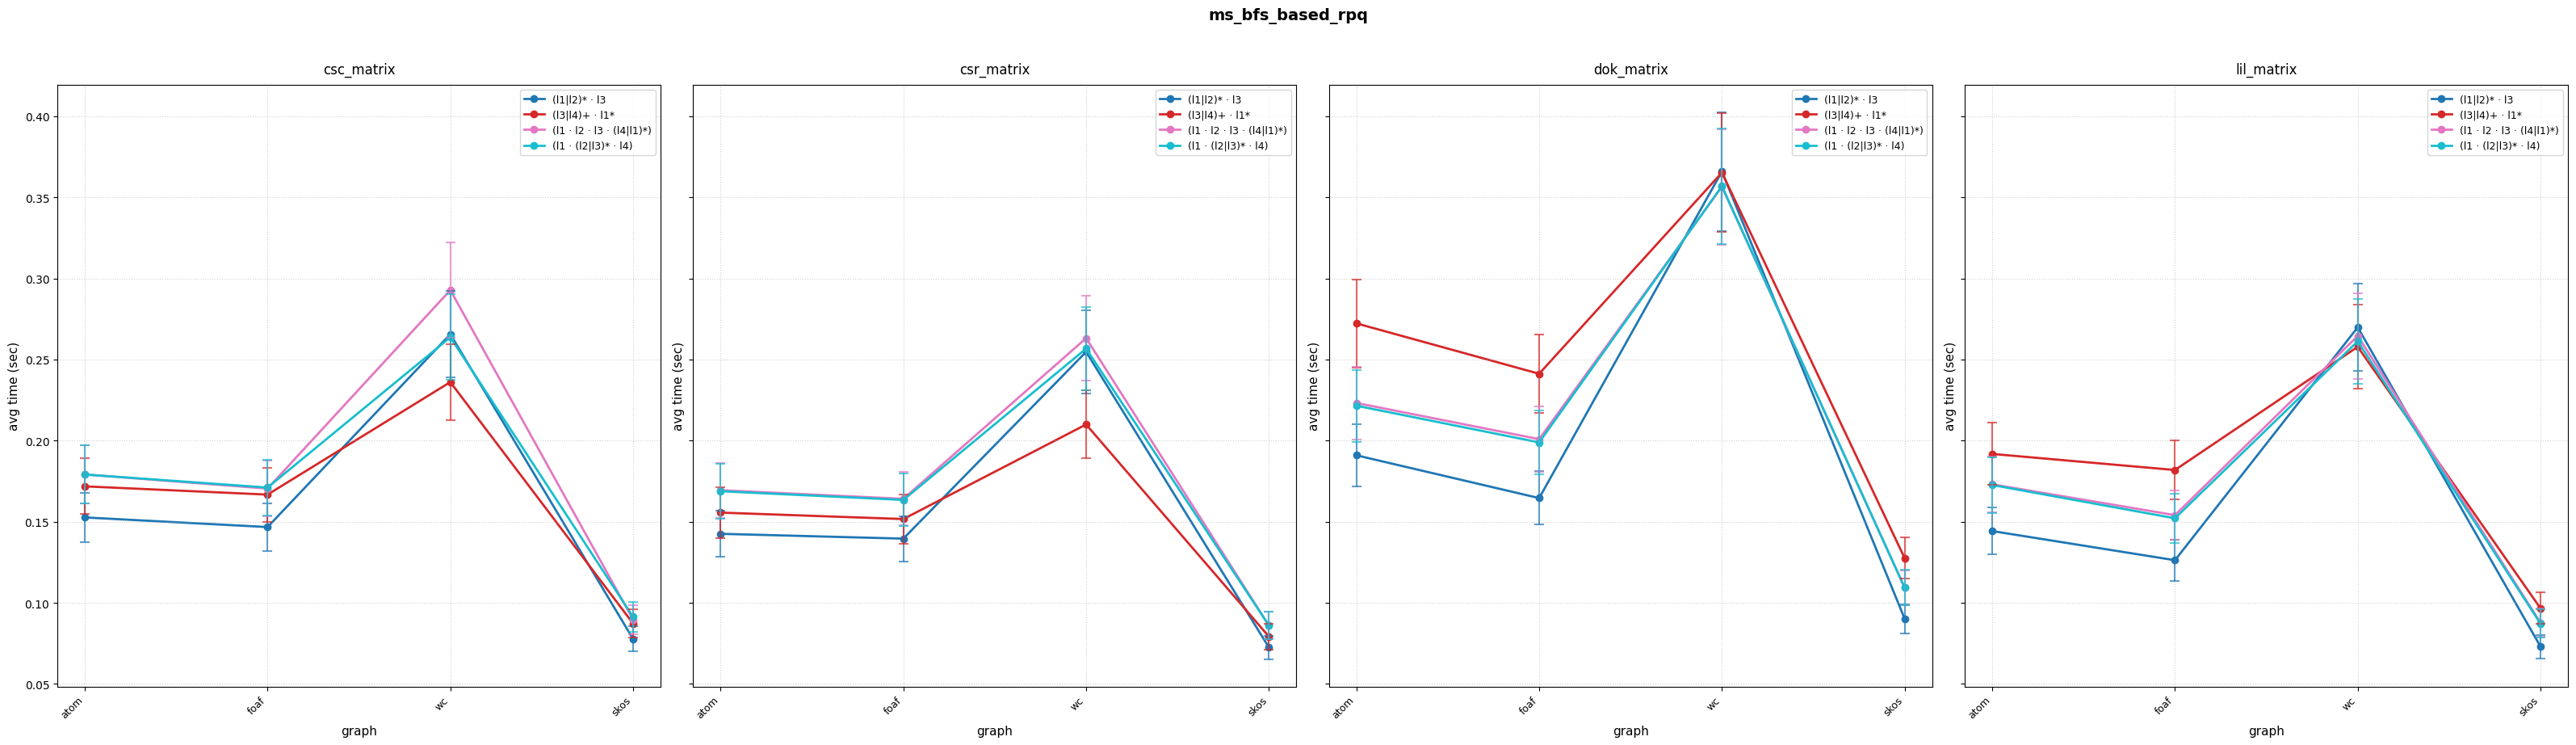

In [22]:
# tensor_based_rpq

METHOD_NAME = "tensor_based_rpq"
method_data_all = df[df["method"] == METHOD_NAME]

regex_colors = plt.cm.tab10(np.linspace(0, 1, len(DF_REGEX)))
graph_names = list(graphs.keys())

fig, axes = plt.subplots(
    1, len(MATRIX_TYPES), figsize=(8 * len(MATRIX_TYPES), 9), sharey=True
)
fig.suptitle(METHOD_NAME, fontsize=14, fontweight="bold", y=1.02)

for idx, matrix_type in enumerate(MATRIX_TYPES):
    ax = axes[idx]
    matrix_data = method_data_all[method_data_all["matrix"] == matrix_type]
    all_y_vals = []

    for regex_idx, regex in enumerate(DF_REGEX):
        regex_data = matrix_data[matrix_data["regex_template"] == regex]
        x_vals, y_vals, yerr_vals = [], [], []

        for g_idx, graph_name in enumerate(graph_names):
            row = regex_data[regex_data["graph"] == graph_name]
            if not row.empty:
                mean_time = row["avg_time"].iloc[0]
                x_vals.append(g_idx)
                y_vals.append(mean_time)
                yerr_vals.append(mean_time * 0.1)

        if not x_vals:
            continue

        all_y_vals.extend(y_vals)
        color = regex_colors[regex_idx]
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            linestyle="-",
            color=color,
            label=regex,
            zorder=1,
            linewidth=2,
            markersize=6,
        )
        ax.errorbar(
            x_vals,
            y_vals,
            yerr=yerr_vals,
            fmt="none",
            ecolor=color,
            alpha=0.7,
            capsize=4,
            capthick=1.5,
            zorder=2,
        )

    ax.set_title(f"{matrix_type}", fontsize=12, pad=10)
    ax.set_xlabel("graph", fontsize=11)
    ax.set_ylabel("avg time (sec)", fontsize=11)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6, zorder=0)
    ax.set_xticks(range(len(graph_names)))
    ax.set_xticklabels(graph_names, rotation=45, ha="right", fontsize=9)

    if all_y_vals:
        y_min, y_max = min(all_y_vals), max(all_y_vals)
        y_range = y_max - y_min
        ax.set_ylim(max(0, y_min - y_range * 0.1), y_max + y_range * 0.2)

plt.tight_layout()
plt.show()

# ms_bfs_based_rpq

METHOD_NAME = "ms_bfs_based_rpq"
method_data_all = df[df["method"] == METHOD_NAME]

fig, axes = plt.subplots(
    1, len(MATRIX_TYPES), figsize=(8 * len(MATRIX_TYPES), 9), sharey=True
)
fig.suptitle(METHOD_NAME, fontsize=14, fontweight="bold", y=1.02)

for idx, matrix_type in enumerate(MATRIX_TYPES):
    ax = axes[idx]
    matrix_data = method_data_all[method_data_all["matrix"] == matrix_type]
    all_y_vals = []

    for regex_idx, regex in enumerate(DF_REGEX):
        regex_data = matrix_data[matrix_data["regex_template"] == regex]
        x_vals, y_vals, yerr_vals = [], [], []

        for g_idx, graph_name in enumerate(graph_names):
            row = regex_data[regex_data["graph"] == graph_name]
            if not row.empty:
                mean_time = row["avg_time"].iloc[0]
                x_vals.append(g_idx)
                y_vals.append(mean_time)
                yerr_vals.append(mean_time * 0.1)

        if not x_vals:
            continue

        all_y_vals.extend(y_vals)
        color = regex_colors[regex_idx]
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            linestyle="-",
            color=color,
            label=regex,
            zorder=1,
            linewidth=2,
            markersize=6,
        )
        ax.errorbar(
            x_vals,
            y_vals,
            yerr=yerr_vals,
            fmt="none",
            ecolor=color,
            alpha=0.7,
            capsize=4,
            capthick=1.5,
            zorder=2,
        )

    ax.set_title(f"{matrix_type}", fontsize=12, pad=10)
    ax.set_xlabel("graph", fontsize=11)
    ax.set_ylabel("avg time (sec)", fontsize=11)
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6, zorder=0)
    ax.set_xticks(range(len(graph_names)))
    ax.set_xticklabels(graph_names, rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.show()

### Общие наблюдения

В двух методах по отдельности, по всем конфигурациям наблюдается общий паттерн производительности на графах и по регулярным выражениями, а также узкий доверительный интервал, что говорит о стабильности замеров. 
Можно заметить, что от сложности регулярного выражения увеличивается время производительности алгоритмов. Под сложностью регулярного выражения подразумевается насколько много состояний в графе порождает это регулярное выражение.

Также, заметим несколько интересных моментов, которые рассмотрим подробнее:

1. Вспывающее предупреждение ```SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.```
2. Tensor-based RPQ почти не отличаются по производительности, вне зависимости от формата разреженных матриц.
3. MS-BFS RPQ дал наихудший результат в формате DOK относительно других форматов матриц.


### Объяснение результатов

#### 1. Tensor-based RPQ почти не отличаются по производительности, вне зависимости от формата разреженных матриц

Можно проверить, как преобразуется матрица в процессе матричного умножения. Потому что есть подозрения, что формат не меняется.

In [ ]:
class AdjacencyMatrixFA:
    def __init__(self, fa: NondeterministicFiniteAutomaton):
        graph = fa.to_networkx()
        self.state_index = {state: idx for idx, state in enumerate(graph.nodes)}
        self.index_state = {idx: state for state, idx in self.state_index.items()}
        self.start_state_indices = set(self.state_index[st] for st in fa.start_states)
        self.final_state_indices = set(self.state_index[st] for st in fa.final_states)
        self.number_of_states = graph.number_of_nodes()

        self.adj_matrix = {}
        self.sparse_format = sp.lil_matrix

        for sym in fa.symbols:
            self.adj_matrix[sym] = self.sparse_format(
                (self.number_of_states, self.number_of_states), dtype=bool
            )

        for u, v, label in graph.edges(data="label"):
            if label:
                self.adj_matrix[label][self.state_index[u], self.state_index[v]] = True

    def to_sparse_format(self, sparse_format: str):
        if sparse_format == "lil":
            return
        elif sparse_format == "csc":
            sparse_format = sp.csc_matrix
        elif sparse_format == "csr":
            sparse_format = sp.csr_matrix
        elif sparse_format == "dok":
            sparse_format = sp.dok_matrix

        self.sparse_format = sparse_format

        self.adj_matrix = {
            sym: sparse_format(mat) for sym, mat in self.adj_matrix.items()
        }

    def accepts(self, word: Iterable[Symbol]) -> bool:
        symbols = list(word)
        configs = [(st, symbols) for st in self.start_state_indices]

        while len(configs) > 0:
            state, rest = configs.pop()
            if not rest:
                if state in self.final_state_indices:
                    return True
                continue

            for next_state in range(self.number_of_states):
                if self.adj_matrix[rest[0]][state, next_state]:
                    configs.append((next_state, rest[1:]))
        return False

    def transitive_closure(self):
        init_matrix = self.sparse_format(
            (self.number_of_states, self.number_of_states), dtype=bool
        )
        init_matrix.setdiag(True)

        if not self.adj_matrix:
            return init_matrix

        reach = self.sparse_format(
            (self.number_of_states, self.number_of_states), dtype=bool
        )
        for matrix in self.adj_matrix.values():
            reach += matrix

        result = reach.copy()
        result.setdiag(True)

        print(f"transitive closure type before matrix mult: {type(result)}")

        prev_nnz = 0
        current_nnz = result.nnz

        while current_nnz != prev_nnz:
            prev_nnz = current_nnz
            result = result * result
            result = result > 0
            result.setdiag(True)
            current_nnz = result.nnz

        print(f"transitive closure type after matrix mult: {type(result)}")

        return result

    def is_empty(self) -> bool:
        tc = self.transitive_closure()
        for start in self.start_state_indices:
            for final in self.final_state_indices:
                if tc[start, final]:
                    return False

        return True


def intersect_automata(
    mfa1: AdjacencyMatrixFA,
    mfa2: AdjacencyMatrixFA,
    sparse_format: str,
) -> AdjacencyMatrixFA:
    intersection = AdjacencyMatrixFA(NondeterministicFiniteAutomaton())

    intersection.number_of_states = mfa1.number_of_states * mfa2.number_of_states

    intersection.state_index = {}

    for st1 in mfa1.state_index:
        for st2 in mfa2.state_index:
            index = (
                mfa1.state_index[st1] * mfa2.number_of_states + mfa2.state_index[st2]
            )
            intersection.state_index[(st1, st2)] = index

    intersection.index_state = {
        idx: state for state, idx in intersection.state_index.items()
    }

    intersection.start_state_indices = set()

    for s1 in mfa1.start_state_indices:
        for s2 in mfa2.start_state_indices:
            index = s1 * mfa2.number_of_states + s2
            intersection.start_state_indices.add(index)

    intersection.final_state_indices = set()

    for f1 in mfa1.final_state_indices:
        for f2 in mfa2.final_state_indices:
            index = f1 * mfa2.number_of_states + f2
            intersection.final_state_indices.add(index)

    intersection.adj_matrix = {}

    for sym, adj1 in mfa1.adj_matrix.items():
        if sym not in mfa2.adj_matrix:
            continue

        adj2 = mfa2.adj_matrix[sym]
        intersection.adj_matrix[sym] = kron(adj1, adj2, format=sparse_format)

    intersection.to_sparse_format(sparse_format)

    return intersection


def test_tensor_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    sparse_format: str,
) -> set[tuple[int, int]]:
    all_nodes = {int(n) for n in graph.nodes}
    start_nodes = start_nodes or all_nodes
    final_nodes = final_nodes or all_nodes

    graph_mfa = AdjacencyMatrixFA(graph_to_nfa(graph, start_nodes, final_nodes))
    regex_dfa = regex_to_dfa(regex)
    regex_mfa = AdjacencyMatrixFA(regex_dfa)

    graph_mfa.to_sparse_format(sparse_format)
    regex_mfa.to_sparse_format(sparse_format)

    intersection_mfa = intersect_automata(graph_mfa, regex_mfa, sparse_format)

    tc = intersection_mfa.transitive_closure()

    result = set()
    for start in start_nodes:
        for final in final_nodes:
            for regex_start in regex_dfa.start_states:
                for regex_final in regex_dfa.final_states:
                    if tc[
                        intersection_mfa.state_index[(start, regex_start)],
                        intersection_mfa.state_index[(final, regex_final)],
                    ]:
                        result.add((start, final))

    return result

In [45]:
test_graph = graphs["wc"]

print("LIL")
test_tensor_based_rpq(
    "(d (a|d)* a)", test_graph, test_graph.nodes, test_graph.nodes, sparse_format="lil"
)

print("DOK")
test_tensor_based_rpq(
    "(d (a|d)* a)", test_graph, test_graph.nodes, test_graph.nodes, sparse_format="dok"
)

print("CSC")
test_tensor_based_rpq(
    "(d (a|d)* a)", test_graph, test_graph.nodes, test_graph.nodes, sparse_format="csc"
)

print("CSR")
test_tensor_based_rpq(
    "(d (a|d)* a)", test_graph, test_graph.nodes, test_graph.nodes, sparse_format="csr"
)

LIL
transitive closure type before matrix mult: <class 'scipy.sparse._lil.lil_matrix'>
transitive closure type after matrix mult: <class 'scipy.sparse._csr.csr_matrix'>
DOK
transitive closure type before matrix mult: <class 'scipy.sparse._dok.dok_matrix'>
transitive closure type after matrix mult: <class 'scipy.sparse._csr.csr_matrix'>
CSC
transitive closure type before matrix mult: <class 'scipy.sparse._csc.csc_matrix'>
transitive closure type after matrix mult: <class 'scipy.sparse._csc.csc_matrix'>
CSR
transitive closure type before matrix mult: <class 'scipy.sparse._csr.csr_matrix'>
transitive closure type after matrix mult: <class 'scipy.sparse._csr.csr_matrix'>


{(3, 39),
 (3, 48),
 (9, 63),
 (10, 63),
 (15, 19),
 (15, 71),
 (15, 149),
 (17, 18),
 (17, 36),
 (22, 18),
 (22, 36),
 (22, 43),
 (22, 56),
 (28, 29),
 (28, 76),
 (32, 200),
 (42, 18),
 (42, 36),
 (42, 56),
 (43, 18),
 (43, 36),
 (43, 56),
 (61, 54),
 (67, 197),
 (69, 57),
 (69, 58),
 (72, 66),
 (72, 211),
 (72, 237),
 (75, 29),
 (75, 76),
 (83, 39),
 (83, 48),
 (105, 57),
 (105, 58),
 (111, 106),
 (111, 107),
 (113, 90),
 (113, 91),
 (120, 39),
 (120, 48),
 (125, 194),
 (147, 66),
 (147, 211),
 (147, 237),
 (167, 168),
 (167, 235),
 (169, 39),
 (169, 48),
 (171, 48),
 (172, 106),
 (172, 107),
 (186, 66),
 (186, 211),
 (186, 237),
 (187, 122),
 (192, 136),
 (195, 35),
 (198, 194),
 (201, 90),
 (201, 91),
 (202, 90),
 (202, 91),
 (207, 144),
 (223, 178),
 (229, 18),
 (229, 36),
 (231, 25),
 (231, 87),
 (231, 90),
 (231, 91),
 (236, 2),
 (236, 74),
 (245, 2),
 (245, 74),
 (251, 25),
 (251, 87),
 (251, 90),
 (251, 91),
 (253, 66),
 (253, 211),
 (253, 237),
 (257, 154),
 (258, 106),
 (258

Так и оказалось. Матрица внутри вычисления транзитивного замыкания на первом же умножении любой тип матрицы, кроме CSC, приводится к CSR. Поиск транзитвного замыкания является единственной дорогой операцией в этом алгоритме, поэтому преобразование к одному и тому же типу разреженных матриц дает одинаковые результаты вычислений.

#### 2. MS-BFS RPQ дал наихудший результат в формате DOK относительно других форматов матриц

Можно заметить, что в MS-BFS все форматы матриц, кроме DOK, почти одинаковы в производительности. Если CSC и CSR форматы известны тем, что предназанчены для работы с матричными операциями, то формат LIL показал неочевидный хороший результат в сравнении с DOK. Поменяем код в алгоритме MS-BFS, определив явно промежуточные переменные и посмотрим, какие операции выполняются дольше всего, а также посмотрим, как меняется тип матриц после умножения, так как из прошлого наблюдения стало известно, что бибиотека SciPy меняет тип матриц при умножении in-place

In [43]:
def test_ms_bfs_based_rpq(
    regex: str,
    graph: MultiDiGraph,
    start_nodes: set[int],
    final_nodes: set[int],
    sparse_format: Type[sp.spmatrix] = sp.lil_matrix,
) -> set[tuple[int, int]]:
    dfa_adj_matrix = AdjacencyMatrixFA(regex_to_dfa(regex), sparse_format)
    nfa_adj_matrix = AdjacencyMatrixFA(
        graph_to_nfa(graph, start_nodes, final_nodes), sparse_format
    )

    nfa_st_ids = {i: state for i, state in enumerate(nfa_adj_matrix.state_index)}

    labels = dfa_adj_matrix.adj_matrix.keys() & nfa_adj_matrix.adj_matrix.keys()

    transposed = {label: dfa_adj_matrix.adj_matrix[label].T for label in labels}

    start_states = [
        (dfa_st, nfa_st)
        for dfa_st, nfa_st in product(
            dfa_adj_matrix.start_state_indices, nfa_adj_matrix.start_state_indices
        )
    ]

    k = len(dfa_adj_matrix.state_index.keys())
    m = len(nfa_adj_matrix.state_index.keys())

    def init_front():
        matrices = []
        for dfa_idx, nfa_idx in start_states:
            matrix = sparse_format((k, m), dtype=bool)
            matrix[dfa_idx, nfa_idx] = True
            matrices.append(matrix)
        return vstack(matrices, format=sparse_format([[]]).getformat(), dtype=bool)

    front = init_front()
    visited = front

    while front.nnz > 0:
        new_front = []

        for label in labels:
            sym_front = front @ nfa_adj_matrix.adj_matrix[label]

            temp_matrices = []

            for i in range(len(start_states)):
                start_idx = k * i
                end_idx = k * (i + 1)
                sliced_matrix = sym_front[start_idx:end_idx]

                multiplied = transposed[label] @ sliced_matrix

                temp_matrices.append(multiplied)

            vstack_result = vstack(temp_matrices)
            new_front.append(vstack_result)

            # new_front.append(
            #     vstack(
            #         [
            #             transposed[label] @ sym_front[k * i : k * (i + 1)]
            #             for i in range(len(start_states))
            #         ]
            #     )
            # )

        front = reduce(lambda x, y: x + y, new_front, front) > visited
        visited += front

    res = set()

    for final_dfa in dfa_adj_matrix.final_state_indices:
        for i, start in enumerate(nfa_adj_matrix.start_state_indices):
            reached_states = visited[k * i : k * (i + 1)].getrow(final_dfa).indices

            for reached in reached_states:
                if reached in nfa_adj_matrix.final_state_indices:
                    res.add((nfa_st_ids[start], nfa_st_ids[reached]))

    return res


Выведем типы до и после матричных преобразований

In [35]:
test_graph = graphs["wc"]

test_ms_bfs_based_rpq("(d|a)+ d*",
                      test_graph,
                      test_graph.nodes,
                      test_graph.nodes,
                      sp.dok_matrix)

front type before algo iterations: <class 'scipy.sparse._dok.dok_matrix'>
sym front type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.sparse._csr.csr_matrix'>
sliced matrix type: <class 'scipy.sparse._csr.csr_matrix'>
multiplied T and sliced type: <class 'scipy.

{(0, 0),
 (0, 1),
 (0, 18),
 (0, 36),
 (1, 1),
 (2, 2),
 (2, 74),
 (3, 3),
 (3, 4),
 (4, 4),
 (4, 39),
 (5, 5),
 (5, 6),
 (6, 6),
 (6, 90),
 (6, 91),
 (7, 7),
 (7, 8),
 (8, 8),
 (8, 66),
 (9, 9),
 (9, 10),
 (9, 46),
 (10, 10),
 (10, 46),
 (11, 11),
 (11, 12),
 (12, 12),
 (13, 13),
 (13, 14),
 (14, 14),
 (15, 15),
 (15, 16),
 (16, 16),
 (16, 19),
 (16, 71),
 (16, 149),
 (17, 17),
 (17, 18),
 (17, 321),
 (18, 18),
 (18, 36),
 (18, 321),
 (19, 19),
 (20, 2),
 (20, 20),
 (20, 21),
 (21, 21),
 (22, 22),
 (22, 23),
 (23, 23),
 (23, 43),
 (24, 24),
 (24, 25),
 (24, 87),
 (25, 25),
 (25, 87),
 (26, 26),
 (26, 27),
 (27, 27),
 (28, 28),
 (28, 29),
 (29, 29),
 (29, 76),
 (30, 30),
 (30, 31),
 (31, 31),
 (32, 32),
 (32, 33),
 (33, 33),
 (33, 200),
 (34, 34),
 (34, 35),
 (35, 35),
 (36, 18),
 (36, 36),
 (37, 1),
 (37, 37),
 (38, 38),
 (38, 39),
 (39, 39),
 (39, 48),
 (40, 40),
 (40, 41),
 (41, 41),
 (42, 42),
 (42, 43),
 (42, 55),
 (43, 43),
 (43, 55),
 (44, 44),
 (44, 45),
 (45, 45),
 (46, 46),
 

Для наблюдения измнения типов внутри алгоритма, возьмем работу алгоритма с форматом DOK. Изначально матрица фронта по символу имеет исходный тип CSR, так как она появляется путем умножения фронта с исходным типом (DOK) на булеву декомпозицию матрицы смежности графа (DOK). А как мы уже обнаружили, SciPy меняет формат матрицы после умножения. Теперь внутри цикла мы все время работаем с типом CSR. 

Пройдемся профилировщиком для замера производительности каждого блока кода

In [44]:
from line_profiler import LineProfiler

test_graph = graphs["wc"]

def profile_ms_bfs(sparse_format, name):
    print(f"\n=== {name} ===")
    lp = LineProfiler()
    lp.add_function(test_ms_bfs_based_rpq)
    lp(test_ms_bfs_based_rpq)(
        "(d|a)+ d*",
        test_graph,
        test_graph.nodes,
        test_graph.nodes,
        sparse_format=sparse_format,
    )
    lp.print_stats()

In [45]:
profile_ms_bfs(sp.dok_matrix, "DOK")
profile_ms_bfs(sp.csr_matrix, "CSR")
profile_ms_bfs(sp.lil_matrix, "LIL")
profile_ms_bfs(sp.csc_matrix, "CSC")


=== DOK ===
Timer unit: 1e-09 s

Total time: 1.80116 s
File: /var/folders/q2/v_nv6b757q9dkq3crngyz95w0000gn/T/ipykernel_3057/1801500679.py
Function: test_ms_bfs_based_rpq at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def test_ms_bfs_based_rpq(
     2                                               regex: str,
     3                                               graph: MultiDiGraph,
     4                                               start_nodes: set[int],
     5                                               final_nodes: set[int],
     6                                               sparse_format: Type[sp.spmatrix] = sp.lil_matrix,
     7                                           ) -> set[tuple[int, int]]:
     8         1   10382000.0 1.04e+07      0.6      dfa_adj_matrix = AdjacencyMatrixFA(regex_to_dfa(regex), sparse_format)
     9         2   21924000.0  1.1e+07      1.2      nfa_adj_matrix = AdjacencyMatri

Выше было сказано, что внутри цикла для DOK мы всегда работаем с форматом CSR. Однако в строке 66 прозводительность все равно просела внутри цикла, в сравнении с другими замерами форматов матриц.

Дело в том, что матрица ```transposed``` является транспонированной и все еще в формате DOK, так как создали мы ее вне цикла. Транспонирование CSC даёт CSR (аналогично CSR даёт CSC), а транспонирование для DOK и LIL не меняет формат матрицы.

То есть в строке 

```python
53. multiplied = transposed [label] @ sliced_matrix
``` 

происходит умножение DOK матрицы на CSR матрицу. Явно SciPy не выбрасывает никаких ошибок или warning-ов насчет этого. Предположительно, SciPy переводит DOK матрицу в CSR, выполняет умножение, и уже результирующая матрица находится в CSR-формате. Можно заметить, что умножение LIL на CSR матрицу занимает намного меньше времени, практически равное с замером для CSC 

По результатам профилировщика, четко можно увидеть еще одно узкое место, а именно строка 76 нахождения финальных состояний

```python
76. reached_states = visited[k * i : k * (i + 1)].getrow(final_dfa).indices
```

| matrix | Time | % Time |
| --- | --- | --- |
| CSC | 182685000.0 |18.7|
| CSR | 113860000.0 |12.8|
| LIL | 355758000.0 |32.1|
| DOK | 777424000.0 |43.2|

Здесь происходит операция разрезания строк (slicing operation) матрицы ```visited```, находящейся в изначальном формате, т.е нигде в цикле она не использовалась и не переводилась в CSR (кроме момента с сложением ```front``` к ```visited```, но тип матрицы эта операция не меняет). Отсюда можно увидеть, насколько плохо формат DOK поддерживает разрезания строк, в отличие от LIL, который показал себя неплохо, хоть и хуже, чем CSR и CSC.

#### 3. SparseEfficiencyWarning

В основе реализаций алгоритма Tensor-based RPQ и MS-BFS RPQ лежит структура ```AdjacencyMatrixFA```, представляющая конечный автомат в виде разреженной матрицы смежности и хранящая информацию о стартовых и финальных вершинах. Именно в экземпляр этого типа мы изначально передаем желаемый формат разреженной матрицы. После инициализации матрицы типа ```AdjacencyMatrixFA``` в прогонах эксперимента выше, можно увидеть следующее предупреждение, вызванное библиотекой SciPy: 

```SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.``` 

для работы с матрицами типа CSC, и 

```SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.``` 

с матрицами типа CSR. 

При работе с типами LIL и DOK данного предупреждения нет. Дело в том, что добавление элементов в CSR/CSC матрицы меняет структуру хранения этих самых матриц, которые состоят из трех массивов, хранящих в себе ненулевые значения, индексы этих ненулевых значений и расчеты off-сетов для индексации ненулевых элементов каждой строки. При каждом добавлении нового ненулевого элемента пересоздаются все три массива, что не очень выгодно с точки зрения производительности.

```python
for u, v, label in graph.edges(data="label"):
            if label:
                self.adj_matrix[label][self.state_index[u], self.state_index[v]] = True
```

Так что такое изменение структуры CSR/CSC матрицы в моменте заполнения матриц ненулевыми значениями во время работы алгоритма может довольно дорого обходиться (но не в нашем случае, объяснение этому будет дальше). Формат LIL, наоборот, будет хорошо подходить в момент добавления новых элементов, так как хранит матрицу в виде списка строк-пар вида (row_idx, value) для ненулевых элементов, и добавление нового будет приравниваться к простому добавлению новой строки.

Для честности сравнения можно было попробовать изначально строить ```AdjacencyMatrixFA``` в формате LIL, а дальше остальные вычисления проводить в интересующем нас формате. Но есть две сложности: 
1. В MS-BFS немного другая логика с матричными вычислениями. Если мы добавим предварительное хранение ```AdjacencyMatrixFA``` в формате LIL, а дальше остальные вычисления проводить в интересующем нас формате, то это сделает статистику хуже. Дело в том, что в алгоритме MS-BFS мы пользуемся более частым матричным умножением, когда мы в цикле продвигаемся по достижимым состояниям путем умножения транспонированной матрицы смежности графа и матрицы переходов автомата регулярного выражения. То есть изначально идея "сначала преобразуем в LIL, а потом будем считать эффективно" не очень и рабочая даже в теории. Наше произведение нигде не накапливается и не происходит одноразовое преобразования неэффективного типа матрицы в эффективный, а преобразовывать матрицу в другой тип внутри цикла не совсем целеобразно. Форматы LIL и DOK работают очень медленно в терминах выполнения арифметических операций и матричных вычислений, и применяются чаще в случаях необходимости инкрементального построения матрицы или структурного изменения в процессе работы. 
2. В Tensor-based RPQ, как выяснилось, тоже внутри SciPy выполняется преобразование в CSR формат в матричных умножениях и передача других форматов матриц, в том числе и LIL для построения ```AdjacencyMatrixFA```, не влияла сильно на производительность.


### Вопрос 2. Начиная с какого размера стартового множества выгоднее решать задачу для всех пар и выбирать нужные?

Размер стартового множества определяется процентом от общего числа вершин графа, и в качестве рассматриваемых размеров стартовых множеств были выбраны 10%, 30%, 70% и 100% - такой набор позволит рассмотреть большой диапазон значений при относительно небольших количествах запусков.

Проведем замеры для `tensor_based_rpq` и `ms_bfs_based_rpq`, взяв тип матрицы CSR

In [13]:
start_nodes_proportion = [10.0, 30.0, 70.0, 100.0]

In [14]:
def run(method, graph, regex, start_nodes):
    times = []

    for _ in range(NUM_RUNS):
        start_time = time.time()
        if method == "tensor_based_rpq":
            tensor_based_rpq(regex, graph, start_nodes, graph.nodes, csr_matrix)
        elif method == "ms_bfs_based_rpq":
            ms_bfs_based_rpq(regex, graph, start_nodes, graph.nodes, csr_matrix)
        else:
            raise Exception("this algorithm is not supported")

        final_time = time.time()
        times.append(final_time - start_time)

    avg = sum(times) / len(times)

    return avg

In [15]:
results = []

for method in methods:
    for name, graph in graphs.items():
        labels = get_sorted_labels(graph)
        most_common_labels = [label for label, _ in Counter(labels).most_common(4)]
        regexes = build_regex_from_labels(labels)

        print(method)
        print(f"graph {name}")
        print(regexes)

        for start_size in start_nodes_proportion:
            start_nodes = cfpq_data.generate_multiple_source_percent(
                graph, start_size, seed=42
            )

            for regex_idx, regex in enumerate(regexes):
                res_time = run(method, graph, regex, start_nodes=start_nodes)

                results.append(
                    {
                        "method": method,
                        "regex": regex,
                        "regex_template": REGEX_TEMPLATES[regex_idx],
                        "graph": name,
                        "start_size": start_size,
                        "avg_time": res_time,
                    }
                )

tensor_based_rpq
graph atom
['(type|label)* subClassOf', '(subClassOf|comment)+ type*', '(type label subClassOf (comment|type)*)', '(type (label|subClassOf)* comment)']


/Users/kseniia/formal-lang-course/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


tensor_based_rpq
graph foaf
['(type|label)* comment', '(comment|term_status)+ type*', '(type label comment (term_status|type)*)', '(type (label|comment)* term_status)']
tensor_based_rpq
graph wc
['(d|a)* d', '(d|a)+ d*', '(d a d (a|d)*)', '(d (a|d)* a)']
tensor_based_rpq
graph skos
['(type|definition)* isDefinedBy', '(isDefinedBy|label)+ type*', '(type definition isDefinedBy (label|type)*)', '(type (definition|isDefinedBy)* label)']
ms_bfs_based_rpq
graph atom
['(type|label)* subClassOf', '(subClassOf|comment)+ type*', '(type label subClassOf (comment|type)*)', '(type (label|subClassOf)* comment)']
ms_bfs_based_rpq
graph foaf
['(type|label)* comment', '(comment|term_status)+ type*', '(type label comment (term_status|type)*)', '(type (label|comment)* term_status)']
ms_bfs_based_rpq
graph wc
['(d|a)* d', '(d|a)+ d*', '(d a d (a|d)*)', '(d (a|d)* a)']
ms_bfs_based_rpq
graph skos
['(type|definition)* isDefinedBy', '(isDefinedBy|label)+ type*', '(type definition isDefinedBy (label|type)*)',

In [10]:
df = pd.DataFrame(results)
df

,method,regex,regex_template,graph,matrix,avg_time
0,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csc_matrix,0.451683
1,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,csr_matrix,0.444925
2,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,dok_matrix,0.435311
3,tensor_based_rpq,(type|label)* subClassOf,(l1|l2)* · l3,atom,lil_matrix,0.453595
4,tensor_based_rpq,(subClassOf|comment)+ type*,(l3|l4)+ · l1*,atom,csc_matrix,1.250575
...,...,...,...,...,...,...
123,ms_bfs_based_rpq,(type definition isDefinedBy (label|type)*),(l1 · l2 · l3 · (l4|l1)*),skos,lil_matrix,0.087698
124,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csc_matrix,0.091331
125,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,csr_matrix,0.086081
126,ms_bfs_based_rpq,(type (definition|isDefinedBy)* label),(l1 · (l2|l3)* · l4),skos,dok_matrix,0.109267


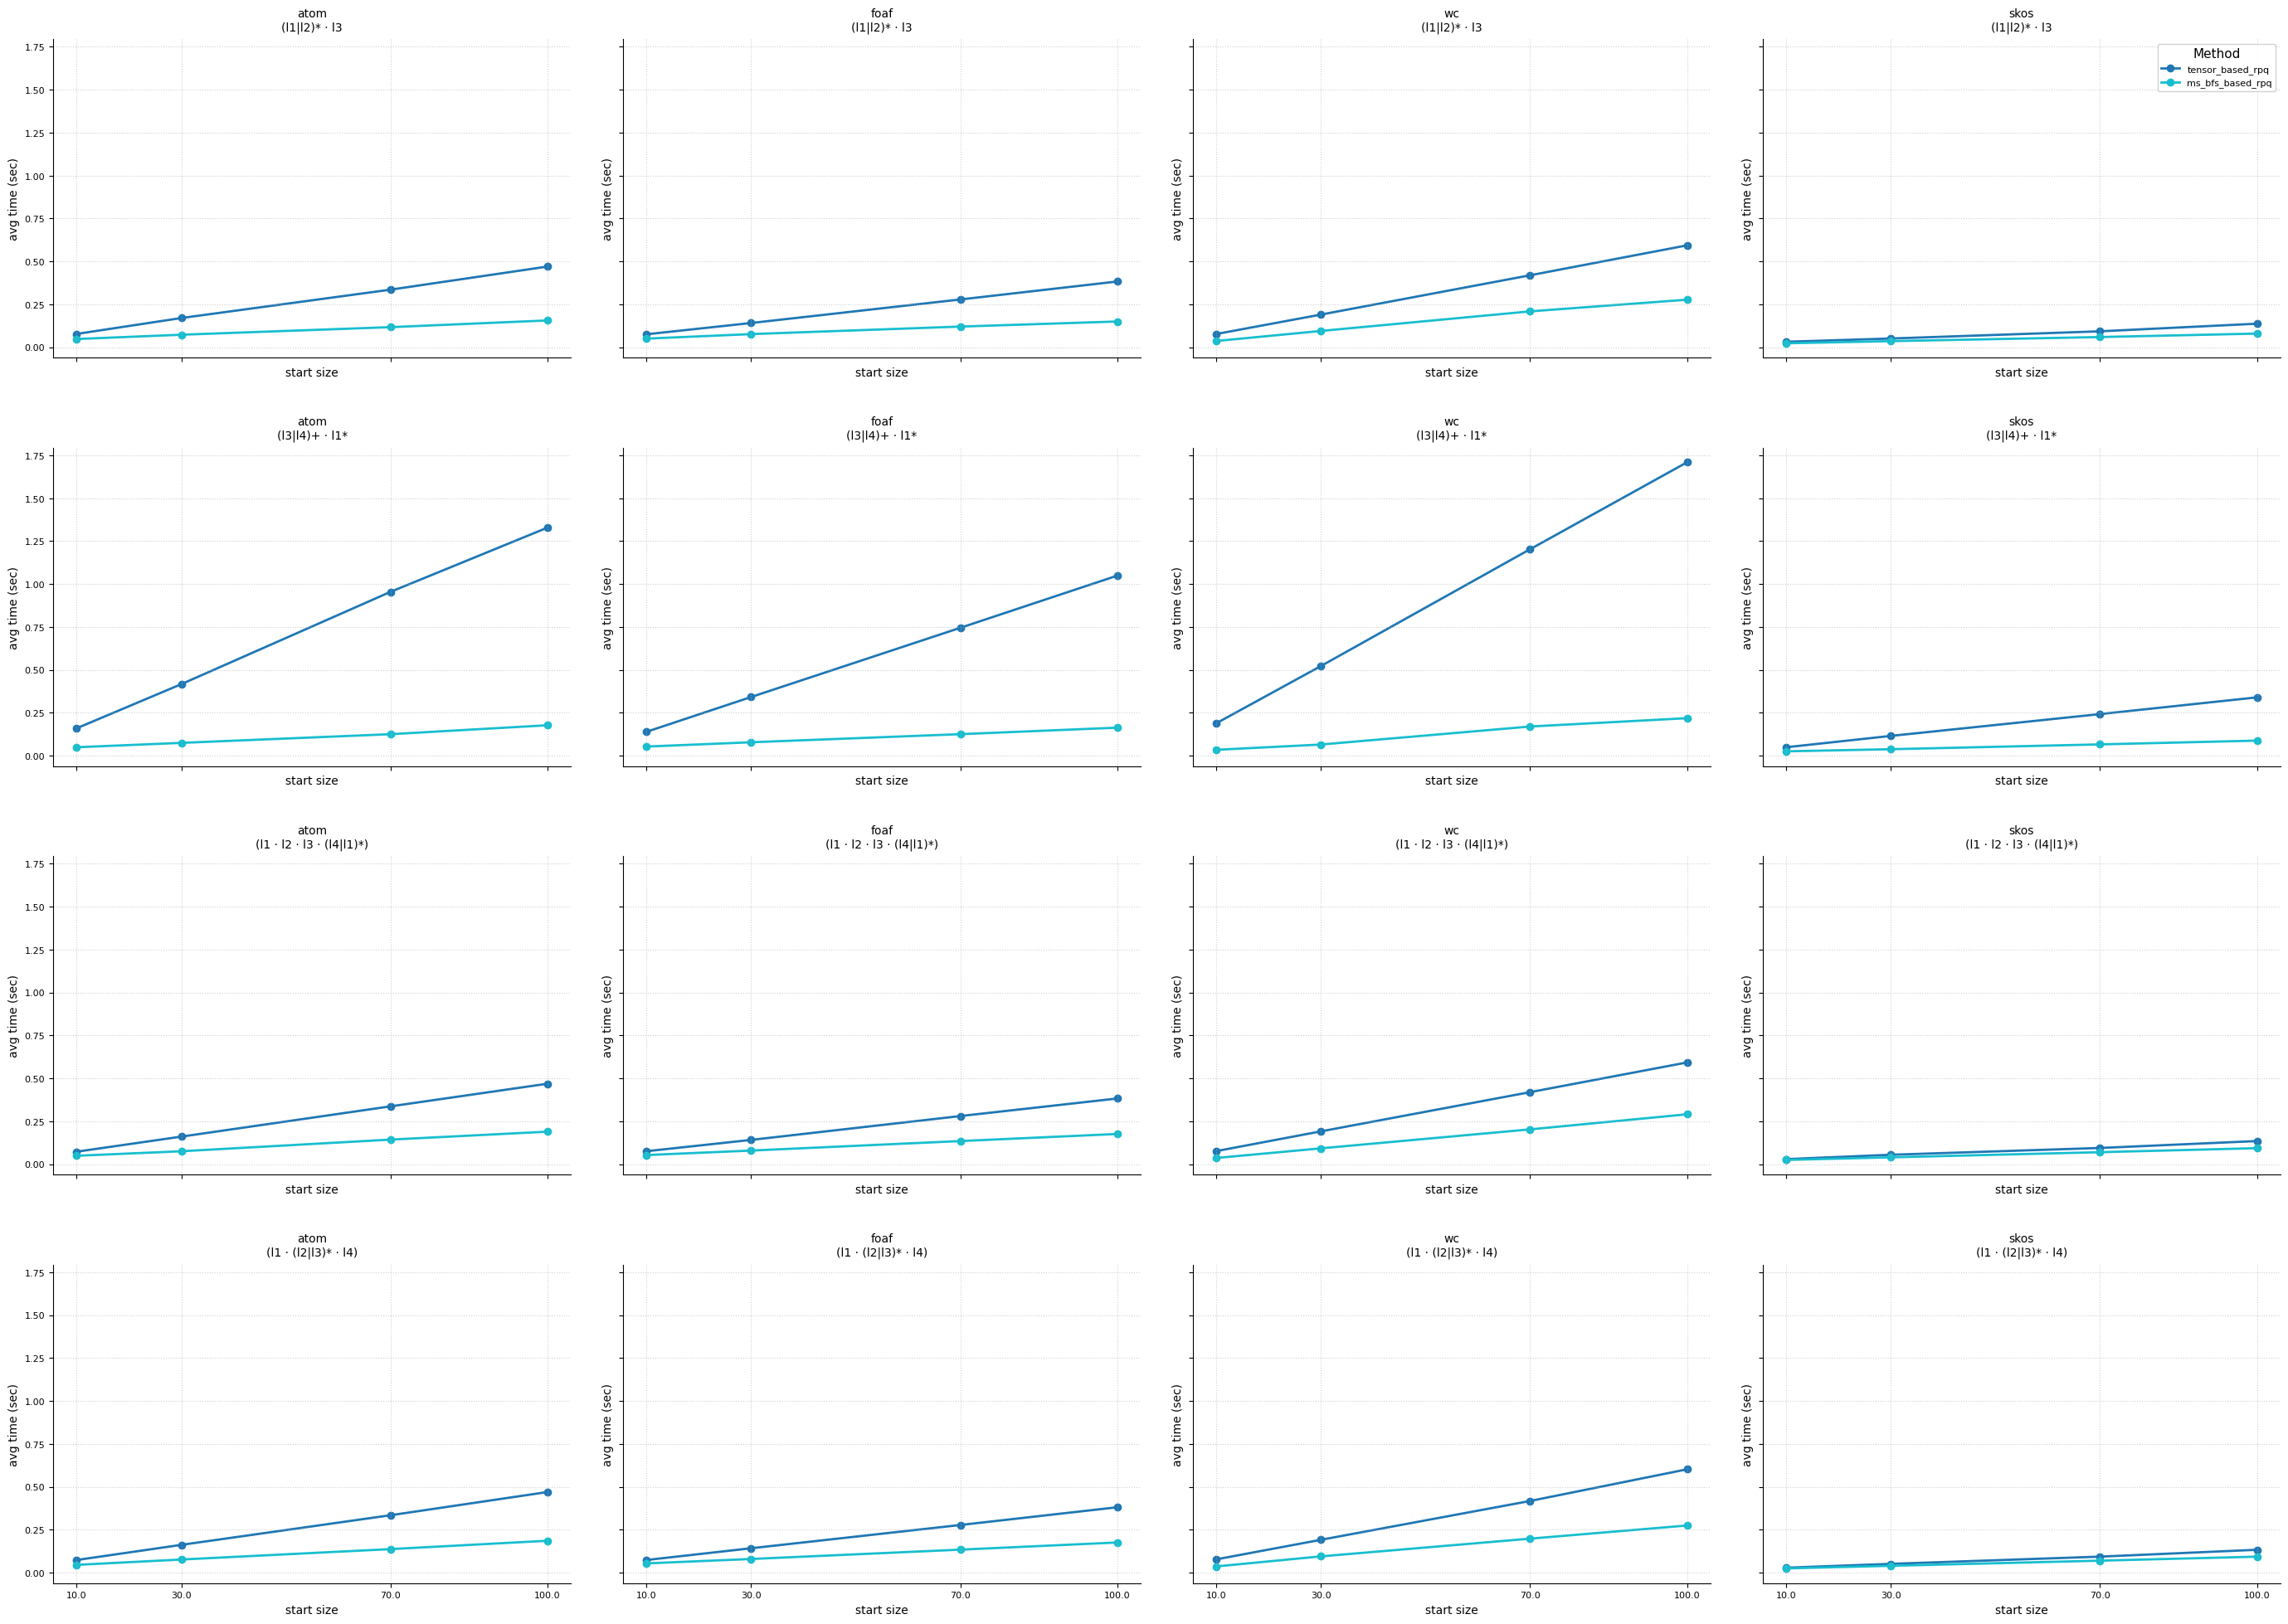

In [34]:
methods = df["method"].unique()
method_colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_color_map = dict(zip(methods, method_colors))

regexes = df["regex_template"].unique()
graphs = df["graph"].unique()
start_sizes = sorted(df["start_size"].unique())


fig, axes = plt.subplots(
    nrows=len(regexes), ncols=len(graphs), figsize=(28, 20), sharey=True, sharex=True
)

for i, regex in enumerate(regexes):
    for j, graph in enumerate(graphs):
        ax = axes[i, j]
        subset = df[(df["regex_template"] == regex) & (df["graph"] == graph)]

        all_y_vals = []

        for method_idx, method in enumerate(methods):
            method_data = subset[subset["method"] == method]

            if method_data.empty:
                continue

            method_data = method_data.sort_values("start_size")
            x_vals = method_data["start_size"].values
            y_vals = method_data["avg_time"].values

            if len(x_vals) == 0:
                continue

            all_y_vals.extend(y_vals)
            color = method_color_map[method]

            ax.plot(
                x_vals,
                y_vals,
                marker="o",
                linestyle="-",
                color=color,
                label=method,
                linewidth=2,
                markersize=6,
                zorder=1,
            )

        ax.set_title(f"{graph}\n{regex}", fontsize=10, pad=8)
        ax.set_xlabel("start size", fontsize=10)
        ax.set_ylabel("avg time (sec)", fontsize=10)

        ax.set_xticks(start_sizes)
        ax.set_xticklabels(start_sizes, fontsize=8)

        ax.grid(True, linestyle=":", alpha=0.6, zorder=0)

        # if all_y_vals:
        #     y_min, y_max = min(all_y_vals), max(all_y_vals)
        #     y_range = y_max - y_min
        #     ax.set_ylim(max(0, y_min - y_range * 0.1), y_max + y_range * 0.2)

        if i == 0 and j == len(graphs) - 1:
            ax.legend(title="Method", fontsize=8, loc="best", framealpha=0.9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", which="major", labelsize=8)

plt.tight_layout(pad=2.0, h_pad=3.0, w_pad=2.5)
plt.show()

### Выводы

Из результатов видно, что с увеличением количества стартовых вершин MS-BFS RPQ начинает показывать себя лучше тензорного в контексте скорости вычислений. Начиная с 30% размера стартового множества, выгоднее использовать алгоритм MS-BFS. 